<font color = 'DodgerBlue'>
<font size = 5>
    
**TAREA. Sismos - ANOVA**

<font color = 'LightSeaGreen'>
<font size = 3>

La tabla [sismos.csv](https://github.com/scidatmath2020/Inferencia_Estadistica_2024/blob/main/data/muestra_aleatoria_sismos.csv) consiste de una **muestra aleatoria** de tamaño 5000 de la información tomada del Servicio Sismológico Nacional de todos los sismos registrados desde el 1 de enero de 1900 hasta las 19:40pm (hora de México DF) del 23 de diciembre de 2023. Realiza con ella un **ANOVA** para:

1. Verificar que la magnitud **promedio** mensual de los sismos en México varía durante todo el año. Es decir, que prácticamente todos los meses tienen su propio nivel de magnitud de sismicidad.

2. Verificar que la magnitud **promedio** mensual de los sismos fuertes (arriba de 6.5) en México es la misma durante todo el año. Es decir, que si te fijas en sismos fuertes ($> 6.5$), todos los meses tienen la misma magnitud **promedio**.

Hay que aplicar una **ANOVA** sin importar la magnitud, tu columna de clasificación va ser el mes en el que ocurrió el sismo. Después, tienes que aplicar un filtro para crear una nueva tabla (puede ser en Excel) y obtener los que tienen magnitud arriba de 6.5 y aplicarle el **ANOVA** a la columna de clasificación "mes".

La idea es verificar que cada mes tiene su propia magnitud de sismicidad con el **ANOVA** (sismos en general). Pero, en cuanto a sismos fuertes, no hay un mes que tienen sismos más fuertes que otro, para tumbar el mito de que en septiempre hay sismos más fuertes.

---

<font color = 'deepskyblue'>
<font size = 5>

Librerías y lectura de los datos 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
import pingouin as pg
import scipy.stats as stats
import random
from distfit import distfit

# Para la pruebas de gaussianidad
from scipy.stats import shapiro, kstest, norm, anderson, jarque_bera

# Para que muestre todas las columnas de los dataframes
pd.set_option('display.max_columns', None)

In [2]:
# Importamos los datos que vamos a usar
data_sismos = pd.read_csv("Data/muestra_aleatoria_sismos.csv")

# Muestra las primeras rows del dataframe
data_sismos.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus,Mes,Mes_nombre
0,17/03/2021,08:54:31,3.0,17.8555,-98.7023,46.3,"37 km al NOROESTE de TLAPA, GRO",17/03/2021,14:54:31,revisado,3,marzo
1,01/05/2017,00:46:29,3.5,15.0717,-93.5760,20.0,"79 km al SUROESTE de PIJIJIAPAN, CHIS",01/05/2017,05:46:29,revisado,5,mayo
2,21/06/1999,03:48:16,3.8,16.3100,-98.3800,36.0,"35 km al OESTE de PINOTEPA NACIONAL, OAX",21/06/1999,08:48:16,revisado,6,junio
3,09/09/2023,04:16:04,3.4,16.8195,-99.3495,8.5,"5 km al NORESTE de SAN MARCOS, GRO",09/09/2023,10:16:04,revisado,9,septiembre
4,01/02/2018,18:38:52,3.6,16.5247,-94.9210,57.4,"11 km al NOROESTE de UNION HIDALGO, OAX",02/02/2018,00:38:52,revisado,2,febrero


In [3]:
print("------------------------------------------")

# Muestra las dimensiones del dataframe
print(f"Dimensiones del dataframe: {data_sismos.shape}")

print("------------------------------------------")

#Muestra las columnas del dataframe
print(data_sismos.columns)

print("------------------------------------------")

# Buscamos valores nulos en la columna de 'Magnitud'
print(f"Valores nulos en la columna 'Magnitud': {data_sismos['Magnitud'].isna().sum()}")

print("------------------------------------------")

# Valores máximo y mínimo de la columna 'Magnitud'
print(f"Magnitud mínima: {data_sismos['Magnitud'].min()}")

print(f"Magnitud máxima: {data_sismos['Magnitud'].max()}")

print("------------------------------------------")

------------------------------------------
Dimensiones del dataframe: (5000, 12)
------------------------------------------
Index(['Fecha', 'Hora', 'Magnitud', 'Latitud', 'Longitud', 'Profundidad',
       'Referencia de localizacion', 'Fecha UTC', 'Hora UTC', 'Estatus', 'Mes',
       'Mes_nombre'],
      dtype='object')
------------------------------------------
Valores nulos en la columna 'Magnitud': 0
------------------------------------------
Magnitud mínima: 0.6
Magnitud máxima: 6.9
------------------------------------------


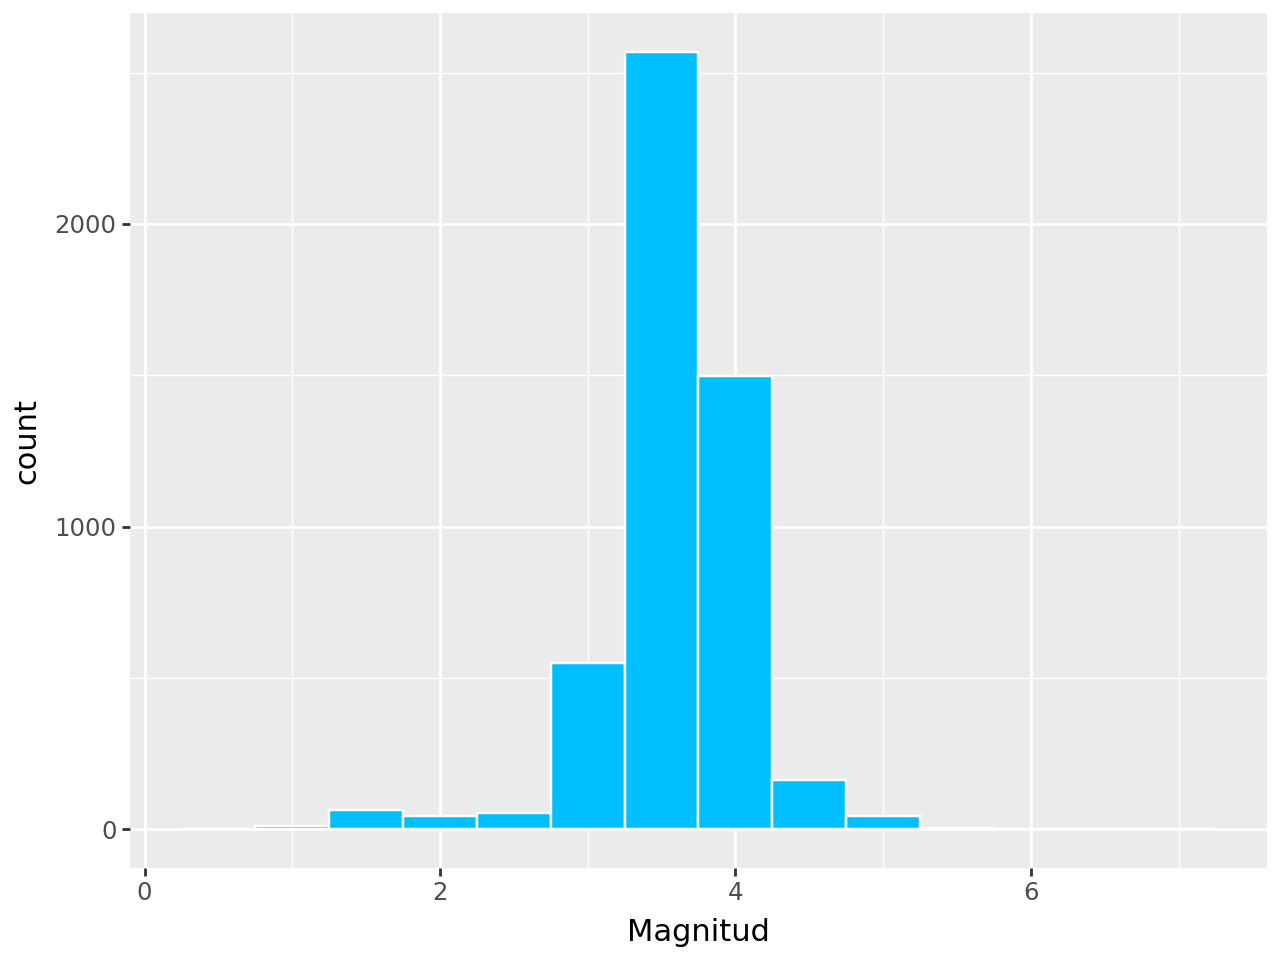

In [4]:
# Histograma de los datos para ver su distribución
(
    ggplot(data = data_sismos) + geom_histogram(mapping = aes(x = "Magnitud"), fill = "deepskyblue", color = "white", binwidth = 0.5)
)

In [5]:
# Extraemos las columnas 'Mes' y 'Magnitud'
sismos = data_sismos[['Mes', 'Magnitud']]

# Se muestran los primeros rows del dataframe
sismos.head()

,Mes,Magnitud
0,3,3.0
1,5,3.5
2,6,3.8
3,9,3.4
4,2,3.6


In [6]:
# Ordenamos los datos por mes desde el 1 hasta el 12
sismos = sismos.sort_values('Mes')

sismos

,Mes,Magnitud
1335,1,3.0
1332,1,1.2
4935,1,3.2
4934,1,4.1
4953,1,3.6
...,...,...
3083,12,3.7
3109,12,3.6
659,12,3.4
4995,12,3.9


<font color = 'deepskyblue'>
<font size = 5>

---

Paso 0) Identificación de parámetros

In [7]:
# Obtenemos los tamaños de cada grupo
sismos.groupby('Mes').size()

Mes
1     449
2     392
3     422
4     355
5     392
6     373
7     356
8     384
9     466
10    473
11    480
12    458
dtype: int64

In [8]:
# Calculamos la media y desviación de cada grupo
sismos.groupby('Mes').agg(['mean', 'std'])

Magnitud          
         mean       std
Mes                    
1    3.648107  0.388969
2    3.580357  0.425344
3    3.621564  0.400812
4    3.661972  0.366833
5    3.647959  0.377969
6    3.610456  0.434436
7    3.611517  0.384864
8    3.584115  0.402061
9    3.494635  0.694984
10   3.497463  0.693121
11   3.584167  0.434089
12   3.564629  0.437035

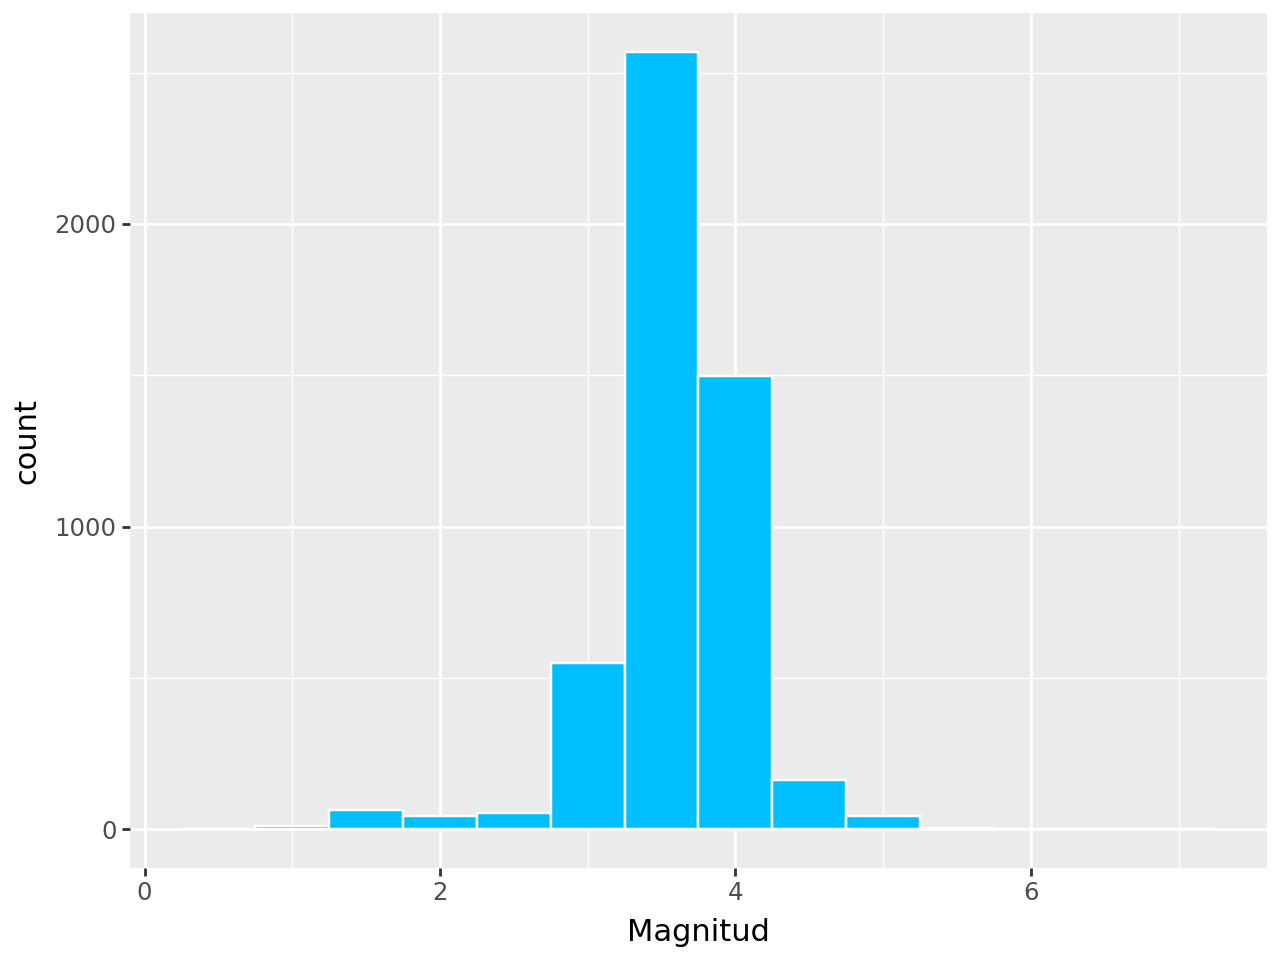

In [9]:
# Histograma de los datos para ver su distribución
(
    ggplot(data = sismos) + geom_histogram(mapping = aes(x = "Magnitud"), fill = "deepskyblue", color = "white", binwidth = 0.5)
)

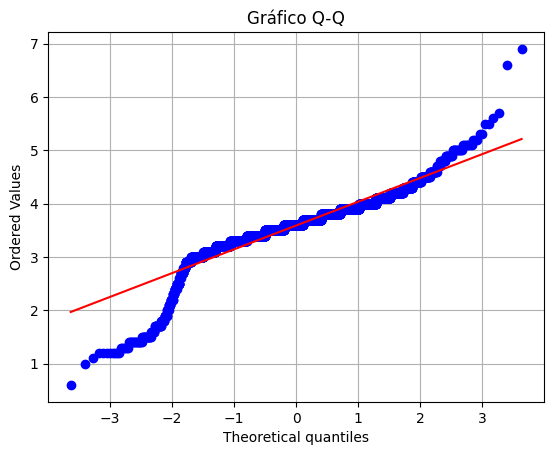

In [10]:
# Gráfico Q-Q
stats.probplot(sismos.Magnitud, dist = "norm", plot = plt)
plt.title("Gráfico Q-Q")
plt.grid(True)
plt.show()

<font color = 'deepskyblue'>
<font size = 5>

---

Paso 1) Prueba de normalidad

In [11]:
# Función para el test de gaussianidad
def gaussian_test(lista):
    shapiro_test = shapiro(lista)
    ks_test = kstest(lista,"norm",args=(np.mean(lista),np.std(lista,ddof=1)))
    jb_test = jarque_bera(lista)
    p_valores = [shapiro_test.pvalue, ks_test.pvalue,jb_test.pvalue] 
#    previos = [x<0.05 for x in p_valores]
    rech = ["Rechazar H0","No rechazar H0"]
    significados = ["Hay buena probabilidad de que NO es gaussiana",
                    "Hay buena probabilidad de que SÍ es gaussiana"]
        
    resultados = pd.DataFrame({"Prueba":["SW","KS","JB"],
     "p_valor":p_valores,
     "Resultado":[rech[0] if x<0.05 else rech[1] for x in p_valores],
     "Interpretación":[significados[0] if x<0.05 else significados[1] for x in p_valores]
    })
    
    anderson_test = anderson(lista,dist="norm")
    est_A = anderson_test.statistic
    resultados_anderson = pd.DataFrame({"Estadístico A":5*[est_A],#,"","","","",""],
                                        "Significancia":anderson_test.significance_level,
                                        "Valor_crítico":anderson_test.critical_values,
                                        "Resultado":[rech[0] if est_A > anderson_test.critical_values[i] else rech[1] for i in range(5)],
                                        "Interpretación":[significados[0] if est_A > anderson_test.critical_values[i] else significados[1] for i in range(5)]})
    return  resultados, resultados_anderson

In [12]:
# Esto devuelve el resultado de la prueba de gaussianidad de cada uno de los 12 grupos
resultados_gaussianidad = sismos.groupby('Mes')['Magnitud'].apply(gaussian_test)

In [13]:
resultados_gaussianidad

Mes
1     ([Prueba, p_valor, Resultado], [Estadístico A,...
2     ([Prueba, p_valor, Resultado], [Estadístico A,...
3     ([Prueba, p_valor, Resultado], [Estadístico A,...
4     ([Prueba, p_valor, Resultado], [Estadístico A,...
5     ([Prueba, p_valor, Resultado], [Estadístico A,...
6     ([Prueba, p_valor, Resultado], [Estadístico A,...
7     ([Prueba, p_valor, Resultado], [Estadístico A,...
8     ([Prueba, p_valor, Resultado], [Estadístico A,...
9     ([Prueba, p_valor, Resultado], [Estadístico A,...
10    ([Prueba, p_valor, Resultado], [Estadístico A,...
11    ([Prueba, p_valor, Resultado], [Estadístico A,...
12    ([Prueba, p_valor, Resultado], [Estadístico A,...
Name: Magnitud, dtype: object

<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 1 (enero)

In [14]:
resultados_gaussianidad[1][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,4.585639e-16,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,9.258289e-05,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,3.377120e-241,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [15]:
resultados_gaussianidad[1][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,6.508956,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,6.508956,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,6.508956,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,6.508956,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,6.508956,1.0,1.082,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 2 (febrero)

In [16]:
resultados_gaussianidad[2][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,5.886639e-11,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,2.014709e-03,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,1.283057e-32,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [17]:
resultados_gaussianidad[2][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,4.888317,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,4.888317,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,4.888317,5.0,0.779,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,4.888317,2.5,0.909,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,4.888317,1.0,1.081,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 3 (marzo)

In [18]:
resultados_gaussianidad[3][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.518405e-12,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,1.478314e-03,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,8.300587e-83,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [19]:
resultados_gaussianidad[3][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,4.73916,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,4.73916,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,4.73916,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,4.73916,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,4.73916,1.0,1.082,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 4 (abril)

In [20]:
resultados_gaussianidad[4][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.069985e-14,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,9.394491e-03,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,0.000000e+00,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [21]:
resultados_gaussianidad[4][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,3.489275,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,3.489275,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,3.489275,5.0,0.778,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,3.489275,2.5,0.908,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,3.489275,1.0,1.080,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 5 (mayo)

In [22]:
resultados_gaussianidad[5][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,4.131767e-11,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,2.546337e-03,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,4.541762e-93,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [23]:
resultados_gaussianidad[5][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,3.59309,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,3.59309,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,3.59309,5.0,0.779,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,3.59309,2.5,0.909,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,3.59309,1.0,1.081,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 6 (junio)

In [24]:
resultados_gaussianidad[6][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,7.505310e-10,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,1.745199e-02,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,2.352605e-45,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [25]:
resultados_gaussianidad[6][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,3.243362,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,3.243362,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,3.243362,5.0,0.779,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,3.243362,2.5,0.908,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,3.243362,1.0,1.081,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 7 (julio)

In [26]:
resultados_gaussianidad[7][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.478705e-11,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,3.355824e-04,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,3.379321e-85,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [27]:
resultados_gaussianidad[7][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,4.067992,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,4.067992,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,4.067992,5.0,0.778,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,4.067992,2.5,0.908,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,4.067992,1.0,1.080,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 8 (agosto)

In [28]:
resultados_gaussianidad[8][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.046973e-13,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,3.027816e-03,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,4.556298e-161,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [29]:
resultados_gaussianidad[8][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,4.694086,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,4.694086,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,4.694086,5.0,0.779,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,4.694086,2.5,0.909,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,4.694086,1.0,1.081,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 9 (septiembre)

In [30]:
resultados_gaussianidad[9][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.238655e-20,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,1.167053e-16,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,1.899484e-60,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [31]:
resultados_gaussianidad[9][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,25.099259,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,25.099259,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,25.099259,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,25.099259,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,25.099259,1.0,1.083,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 10 (octubre)

In [32]:
resultados_gaussianidad[10][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,4.680519e-23,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,8.976468e-22,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,1.612186e-96,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [33]:
resultados_gaussianidad[10][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,31.302649,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,31.302649,10.0,0.651,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,31.302649,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,31.302649,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,31.302649,1.0,1.083,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 11 (noviembre)

In [34]:
resultados_gaussianidad[11][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.729480e-20,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,6.217827e-08,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,0.000000e+00,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [35]:
resultados_gaussianidad[11][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,11.548942,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,11.548942,10.0,0.651,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,11.548942,5.0,0.781,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,11.548942,2.5,0.911,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,11.548942,1.0,1.083,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Resultados para el mes 12 (diciembre)

In [36]:
resultados_gaussianidad[12][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,7.936246e-17,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,2.241818e-06,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,1.109466e-151,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [37]:
resultados_gaussianidad[12][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,8.564524,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,8.564524,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,8.564524,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,8.564524,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,8.564524,1.0,1.083,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


<font color = 'LightSeaGreen'>
<font size = 3>

Observamos que para los 12 grupos no hay **gaussianidad**, por lo que pocedemos a realizar una **transformación** de la columna 'Magnitud' para intentar obtener **gaussianidad**.

---

<font color = 'LightSeaGreen'>
<font size = 3>

**Transformación** de los **datos** con exp.

In [38]:
sismos['Magnitud_exp_transformado'] = np.exp(sismos['Magnitud'])

sismos

,Mes,Magnitud,Magnitud_exp_transformado
1335,1,3.0,20.085537
1332,1,1.2,3.320117
4935,1,3.2,24.532530
4934,1,4.1,60.340288
4953,1,3.6,36.598234
...,...,...,...
3083,12,3.7,40.447304
3109,12,3.6,36.598234
659,12,3.4,29.964100
4995,12,3.9,49.402449


<font color = 'deepskyblue'>
<font size = 5>

---

Paso 1) Prueba de normalidad a los datos transformados

In [39]:
# Esto devuelve el resultado de la prueba de gaussianidad de los datos transformados
resultados_gaussianidad_transformado = sismos.groupby('Mes')['Magnitud_exp_transformado'].apply(gaussian_test)

In [40]:
resultados_gaussianidad_transformado

Mes
1     ([Prueba, p_valor, Resultado], [Estadístico A,...
2     ([Prueba, p_valor, Resultado], [Estadístico A,...
3     ([Prueba, p_valor, Resultado], [Estadístico A,...
4     ([Prueba, p_valor, Resultado], [Estadístico A,...
5     ([Prueba, p_valor, Resultado], [Estadístico A,...
6     ([Prueba, p_valor, Resultado], [Estadístico A,...
7     ([Prueba, p_valor, Resultado], [Estadístico A,...
8     ([Prueba, p_valor, Resultado], [Estadístico A,...
9     ([Prueba, p_valor, Resultado], [Estadístico A,...
10    ([Prueba, p_valor, Resultado], [Estadístico A,...
11    ([Prueba, p_valor, Resultado], [Estadístico A,...
12    ([Prueba, p_valor, Resultado], [Estadístico A,...
Name: Magnitud_exp_transformado, dtype: object

In [41]:
resultados_gaussianidad_transformado[1][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.117576e-24,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,4.841784e-13,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,0.000000e+00,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [42]:
resultados_gaussianidad_transformado[1][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,20.03097,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,20.03097,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,20.03097,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,20.03097,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,20.03097,1.0,1.082,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [43]:
resultados_gaussianidad_transformado[7][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,19.346527,15.0,0.570,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,19.346527,10.0,0.649,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,19.346527,5.0,0.778,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,19.346527,2.5,0.908,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,19.346527,1.0,1.080,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [44]:
# Transformamos los datos con raiz cuadrada y agregamos la nueva columna al dataframe
sismos['Magnitud_sqrt2_transformado'] = np.sqrt(sismos['Magnitud'])

sismos

,Mes,Magnitud,Magnitud_exp_transformado,Magnitud_sqrt2_transformado
1335,1,3.0,20.085537,1.732051
1332,1,1.2,3.320117,1.095445
4935,1,3.2,24.532530,1.788854
4934,1,4.1,60.340288,2.024846
4953,1,3.6,36.598234,1.897367
...,...,...,...,...
3083,12,3.7,40.447304,1.923538
3109,12,3.6,36.598234,1.897367
659,12,3.4,29.964100,1.843909
4995,12,3.9,49.402449,1.974842


In [45]:
# Esto devuelve el resultado de la prueba de gaussianidad de los datos transformados
resultados_gaussianidad_transformado2 = sismos.groupby('Mes')['Magnitud_sqrt2_transformado'].apply(gaussian_test)

In [48]:
resultados_gaussianidad_transformado2[1][0]

,Prueba,p_valor,Resultado,Interpretación
0,SW,1.084155e-19,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,KS,2.859377e-05,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,JB,0.000000e+00,Rechazar H0,Hay buena probabilidad de que NO es gaussiana


In [49]:
resultados_gaussianidad_transformado2[1][1]

,Estadístico A,Significancia,Valor_crítico,Resultado,Interpretación
0,8.170878,15.0,0.571,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
1,8.170878,10.0,0.650,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
2,8.170878,5.0,0.780,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
3,8.170878,2.5,0.910,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
4,8.170878,1.0,1.082,Rechazar H0,Hay buena probabilidad de que NO es gaussiana
